In [1]:
import os
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pyvisa as pv

import labmate
from labmate.acquisition_notebook import AcquisitionAnalysisManager

from utils.naming import make_run_dir

In [2]:
DATA_DIR = "data/oscilloscope"
os.makedirs(DATA_DIR, exist_ok=True)

In [3]:
# FOLDER
SAMPLE = "shg_cavity_lock_svenska10"
MEAS = "oscilloscope_trace"
ACQ_CELL = f"{MEAS}_{SAMPLE}"

RUN_DIR = make_run_dir(data_dir=DATA_DIR, meas=MEAS, sample=SAMPLE)

print("Temperature scan data will be saved in:", RUN_DIR)

Saving data to: data/oscilloscope\oscilloscope_trace\2026-06-11_shg_cavity_lock_svenska10_002
Temperature scan data will be saved in: data/oscilloscope\oscilloscope_trace\2026-06-11_shg_cavity_lock_svenska10_002


In [7]:
rm = pv.ResourceManager()
print(rm.list_resources())

('USB0::0x0699::0x039F::C010359::INSTR', 'ASRL1::INSTR', 'ASRL5::INSTR')


In [8]:
scope = rm.open_resource('USB0::0x0699::0x039F::C010359::INSTR')
print(scope.query('*IDN?'))

TEKTRONIX,DPO2014B,C010359,CF:91.1CT FV:v1.52 



In [10]:
sel = scope.query("SEL?").strip().split(";")

active_channels = []

for i, ch in enumerate(["CH1", "CH2", "CH3", "CH4"]):
    if sel[i] == "1":
        active_channels.append(ch)

print('Active channel(s): ', active_channels)

Active channel(s):  ['CH1', 'CH2']


In [11]:
# Get all displayed channels
aqm = AcquisitionAnalysisManager(RUN_DIR)
aqm.acquisition_cell(ACQ_CELL)

data = {}

# Freeze the scope to get a stable trace
scope.write("ACQ:STATE STOP")

for channel in active_channels:
    scope.write(f"DATA:SOURCE {channel}")
    scope.write("DATA:ENC RIBINARY")
    scope.write("DATA:WIDTH 1")

    y_raw = scope.query_binary_values(
        "CURVE?",
        datatype="b",
        container=np.array
    )

    ymult = float(scope.query("WFMPRE:YMULT?"))
    yoff  = float(scope.query("WFMPRE:YOFF?"))
    yzero = float(scope.query("WFMPRE:YZERO?"))

    xincr = float(scope.query("WFMPRE:XINCR?"))
    xzero = float(scope.query("WFMPRE:XZERO?"))
    pt_off = float(scope.query("WFMPRE:PT_OFF?"))

    y = (y_raw - yoff) * ymult + yzero
    x = xzero + (np.arange(len(y)) - pt_off) * xincr

    data[f"{channel}_x"] = x
    data[f"{channel}_y"] = y
    data[f"{channel}_y_raw"] = y_raw

    data[f"{channel}_ymult"] = ymult
    data[f"{channel}_yoff"] = yoff
    data[f"{channel}_yzero"] = yzero
    data[f"{channel}_xincr"] = xincr
    data[f"{channel}_xzero"] = xzero
    data[f"{channel}_pt_off"] = pt_off

    print(f"Saved {channel}")

    aqm.save_acquisition(**data)

scope.write("ACQ:STATE RUN")

INFO:1:2026_06_11__10_00_42__oscilloscope_trace_shg_cavity_lock_svenska10


Saved CH1
Saved CH2


15

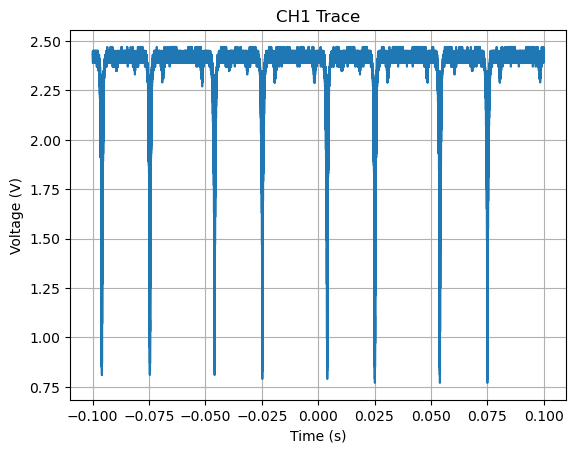

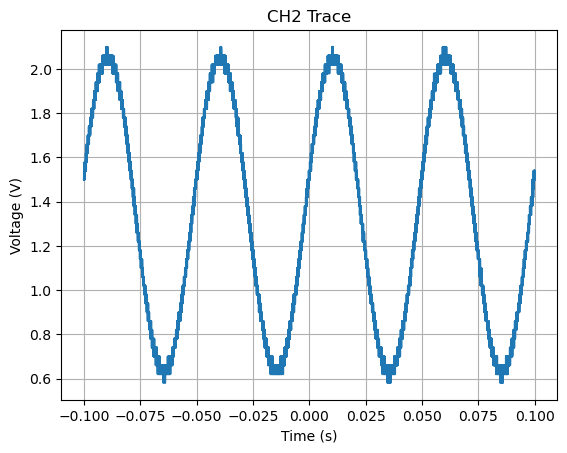

In [12]:
# Quick plot to check
for channel in active_channels:
    plt.figure()
    plt.plot(data[f"{channel}_x"], data[f"{channel}_y"])
    plt.title(f"{channel} Trace")
    plt.xlabel("Time (s)")
    plt.ylabel("Voltage (V)")
    plt.grid()
    plt.show()